In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.iolib.summary2 import summary_col
from scipy.stats import pearsonr
import os
import locale
from pathlib import Path

from google.colab import drive
# ---------------------------------------------------------------------------
# 1. Setup and Data Loading
# ---------------------------------------------------------------------------
# Mount Google Drive
drive.mount('/content/drive')

# Define folder paths
PROCESSED_DATA_FOLDER = Path("/content/drive/MyDrive/Resilient_Housing_Global_Regression/data_processed")
data_file_path = os.path.join(PROCESSED_DATA_FOLDER, "global_analysis_final_for_modeling.csv")

RESULTS_DATA_FOLDER = Path("/content/drive/MyDrive/Resilient_Housing_Global_Regression/Results")


df_analysis = pd.read_csv(data_file_path, encoding='utf-8-sig', low_memory=False)

dep_var = 'VULN_DEFAULT_ROBUSTNESS'
category_b_vars = [
    'WB_POVERTY_GAP_AT_USD4_20_2021PPP_VALUE',
    'WB_GDP_PCAP_PPP_INTL_2021_VALUE',
    'WB_WGI_GOVERNMENT_EFFECTIVENESS_VALUE',
    'WB_DB_BUILDING_QUALITY_INDEX'
]
category_c_vars = ['DIS_EQK', 'DIS_STM', 'DIS_FLD']
all_vars = [dep_var] + category_b_vars + category_c_vars

# Create the fixed analysis sample (N=150)
df_stats = df_analysis.dropna(subset=all_vars).copy()

# Apply log transformations
df_stats['log_GDP'] = np.log(df_stats['WB_GDP_PCAP_PPP_INTL_2021_VALUE'])
df_stats['log_DIS_EQK'] = np.log1p(df_stats['DIS_EQK'])
df_stats['log_DIS_STM'] = np.log1p(df_stats['DIS_STM'])
df_stats['log_DIS_FLD'] = np.log1p(df_stats['DIS_FLD'])
df_stats['log_Land_Area'] = np.log1p(df_stats['WB_LAND_AREA_SQ_KM_VALUE'])
df_stats['log_Precipitation'] = np.log1p(df_stats['WB_AVERAGE_PRECIPITATION_MM_PER_YEAR_VALUE'])

df_stats['DIS_EQK_STM'] = df_stats['DIS_EQK'] + df_stats['DIS_STM']
df_stats['log_DIS_EQK_STM'] = np.log1p(df_stats['DIS_EQK_STM'])

df_stats['DIS_3_HAZARDS'] = df_stats[['DIS_EQK', 'DIS_STM', 'DIS_FLD']].sum(axis=1)
df_stats['log_DIS_3_HAZARDS'] = np.log1p(df_stats['DIS_3_HAZARDS'])

print(f"✅ Analysis Sample Fixed: N = {len(df_stats)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Analysis Sample Fixed: N = 150


# Summary Statistics

In [40]:
# -----------------------------------------------------------------------------
# 2. SUMMARY STATISTICS CALCULATION
# -----------------------------------------------------------------------------

#Key variables to include in the summary stats
category_a_vars = ['VULN_DEFAULT_ROBUSTNESS', 'VULN_DEFAULT_ROBUST_ONLY']
category_b_vars = [
    'WB_POVERTY_GAP_AT_USD4_20_2021PPP_VALUE',
    'WB_GDP_PCAP_PPP_INTL_2021_VALUE',
    'WB_WGI_GOVERNMENT_EFFECTIVENESS_VALUE',
    'WB_DB_BUILDING_QUALITY_INDEX',
]
category_c_vars = [
    'DIS_EQK',
    'DIS_STM',
    'DIS_FLD',
]


summary_vars = category_a_vars + category_b_vars + category_c_vars
summary_stats = df_stats[summary_vars].describe().T
summary_stats = summary_stats[['count', 'mean', 'std', 'min', 'max']]
summary_stats.columns = ['N', 'Mean', 'Std. Dev.', 'Min', 'Max']

# -----------------------------------------------------------------------------
# 3. FORMATTING AND DISPLAY
# -----------------------------------------------------------------------------

variable_label_map_en = {
    'VULN_DEFAULT_ROBUSTNESS': 'Combined Hazards (Robust or Medium)',
    'VULN_DEFAULT_ROBUST_ONLY': 'Combined Hazards (Robust Only)',
    'WB_POVERTY_GAP_AT_USD4_20_2021PPP_VALUE': 'Poverty Gap (%, $4.20/day, 2021 PPP)',
    'WB_GDP_PCAP_PPP_INTL_2021_VALUE': 'GDP per Capita (PPP, Intl $2021) - RAW',
    'WB_WGI_GOVERNMENT_EFFECTIVENESS_VALUE': 'Government Effectiveness (WGI, 2024)',
    'WB_DB_BUILDING_QUALITY_INDEX': 'Building Quality Index (0-15, Doing Business 2020)',
    'DIS_EQK': 'Earthquake Events ',
    'DIS_STM': 'Storm Events ',
    'DIS_FLD': 'Flood Events ',
}

raw_variables_for_int_format = ['WB_GDP_PCAP_PPP_INTL_2021_VALUE', 'DIS_EQK', 'DIS_STM', 'DIS_FLD']

def format_summary_stats(df, label_map):
    formatted_rows = []

    for var_name in df.index:
        label = label_map.get(var_name, var_name)
        row = df.loc[var_name]


        fmt_row = {
            'Variable': label,
            'N': int(row['N'])
        }

        for col in ['Mean', 'Std. Dev.', 'Min', 'Max']:
            val = row[col]
            if var_name in raw_variables_for_int_format:
                fmt_row[col] = f"{val:,.0f}"
            else:
                fmt_row[col] = f"{val:.3f}"

        formatted_rows.append(fmt_row)

    return pd.DataFrame(formatted_rows).set_index('Variable')

formatted_stats = format_summary_stats(summary_stats, variable_label_map_en)


categories_to_print = [
    ('A. Housing Robustness Measures (Cost-Weighted Proportion)', category_a_vars),
    ('B. Socioeconomic and Governance Variables', category_b_vars),
    ('C. Disaster Experience (1990-2023, Event Counts)', category_c_vars)
]

title = f"Table 1: Summary Statistics for Regression Variables (N={len(df_stats)})"
divider = "=" * 100
print(f"{divider}\n{title}\n{divider}")
print(f"{'Variable':<55} | {'N':>4} | {'Mean':>10} | {'Std.Dev':>10} | {'Min':>10} | {'Max':>10} |")
print(":---|---:|---:|---:|---:|---:|")

for header, var_list in categories_to_print:
    print(f"**{header}** | | | | | |")
    for var in var_list:
        label = variable_label_map_en.get(var, var)
        if label in formatted_stats.index:
            row = formatted_stats.loc[label]
            print(f"{label:<55} | {int(row['N']):>4} | {row['Mean']:>10} | {row['Std. Dev.']:>10} | {row['Min']:>10} | {row['Max']:>10} |")

print(divider)

# -----------------------------------------------------------------------------
# 4. CSV EXPORT
# -----------------------------------------------------------------------------
export_df = summary_stats.copy()
export_df.index = export_df.index.map(lambda x: variable_label_map_en.get(x, x))
export_df.index.name = 'Variable'

file_name = "summary_statistics_categorized.csv"
export_file_path = os.path.join(RESULTS_DATA_FOLDER, file_name)
export_df.to_csv(export_file_path, encoding='utf-8-sig')
print(f"✅ Exported to: {export_file_path}")

Table 1: Summary Statistics for Regression Variables (N=150)
Variable                                                |    N |       Mean |    Std.Dev |        Min |        Max |
:---|---:|---:|---:|---:|---:|
**A. Housing Robustness Measures (Cost-Weighted Proportion)** | | | | | |
Combined Hazards (Robust or Medium)                     |  150 |      0.522 |      0.283 |      0.025 |      1.000 |
Combined Hazards (Robust Only)                          |  150 |      0.281 |      0.243 |      0.000 |      1.000 |
**B. Socioeconomic and Governance Variables** | | | | | |
Poverty Gap (%, $4.20/day, 2021 PPP)                    |  150 |      8.581 |     13.049 |      0.000 |     60.300 |
GDP per Capita (PPP, Intl $2021) - RAW                  |  150 |     23,733 |     24,884 |      1,036 |    130,049 |
Government Effectiveness (WGI, 2024)                    |  150 |     -0.059 |      0.942 |     -2.225 |      2.135 |
Building Quality Index (0-15, Doing Business 2020)      |  150 |     10.28

# Correlation Analysis


CORRELATION MATRIX (Lower Triangle)
                       (1) Robustness(M/H) (2) Robustness(H) (3) Poverty Gap (4) Log GDP p.c. (5) Gov. Effectiveness (6) Building Quality (10) Log 3-Haz (11) Urban Pop % (12) Log Land Area
(1) Robustness(M/H)               1.000***                                                                                                                                                  
(2) Robustness(H)                 0.570***          1.000***                                                                                                                                
(3) Poverty Gap                  -0.634***         -0.461***        1.000***                                                                                                                
(4) Log GDP p.c.                  0.637***          0.579***       -0.755***         1.000***                                                                                               
(5) Gov. Effective

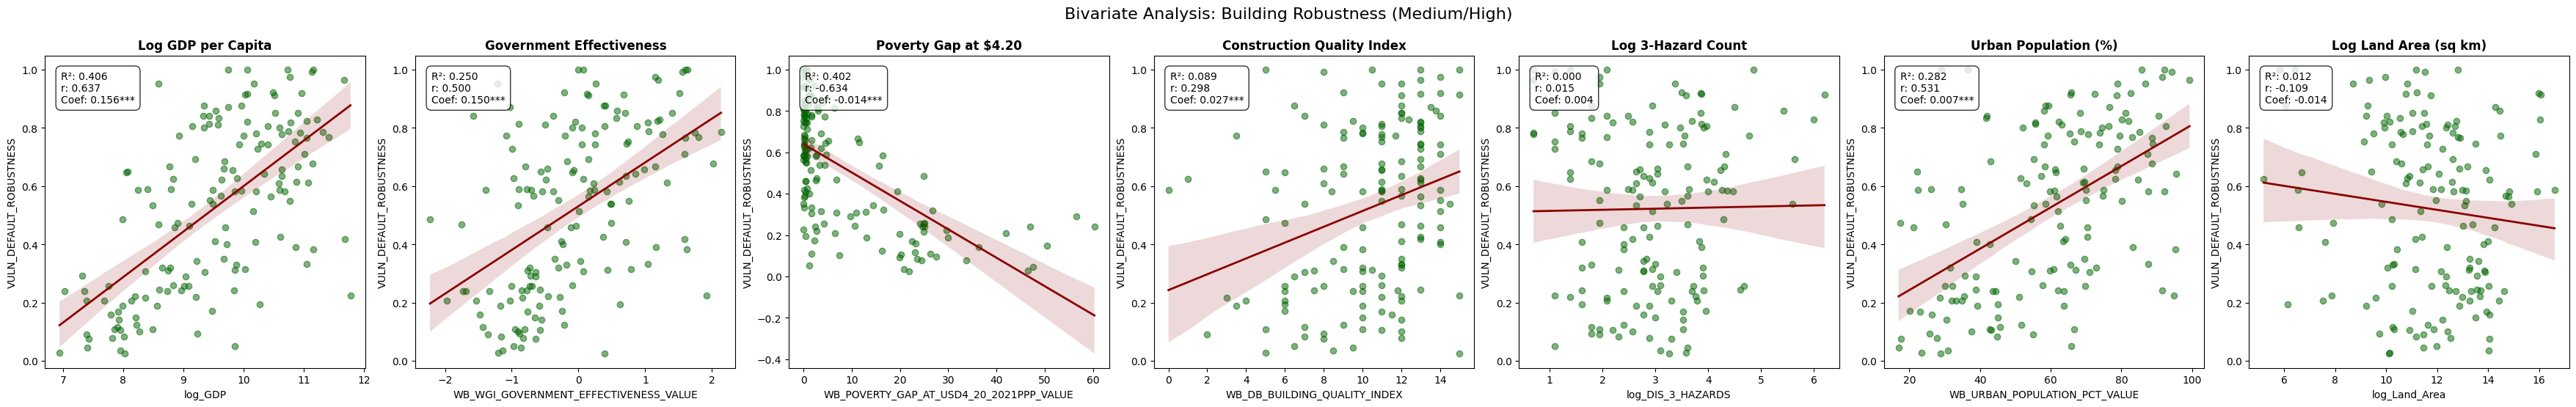

| IV                         | Coef       |   R-squared |   P-value |
|:---------------------------|:-----------|------------:|----------:|
| Log GDP per Capita         | 0.1563***  |      0.4062 |    0      |
| Government Effectiveness   | 0.1503***  |      0.2499 |    0      |
| Poverty Gap at $4.20       | -0.0138*** |      0.4015 |    0      |
| Construction Quality Index | 0.0272***  |      0.0886 |    0.0004 |
| Log 3-Hazard Count         | 0.0038     |      0.0002 |    0.8688 |
| Urban Population (%)       | 0.0071***  |      0.2818 |    0      |
| Log Land Area (sq km)      | -0.0137    |      0.0118 |    0.1912 |

--- Running Analysis for DV: Building Robustness (Highest Only) ---


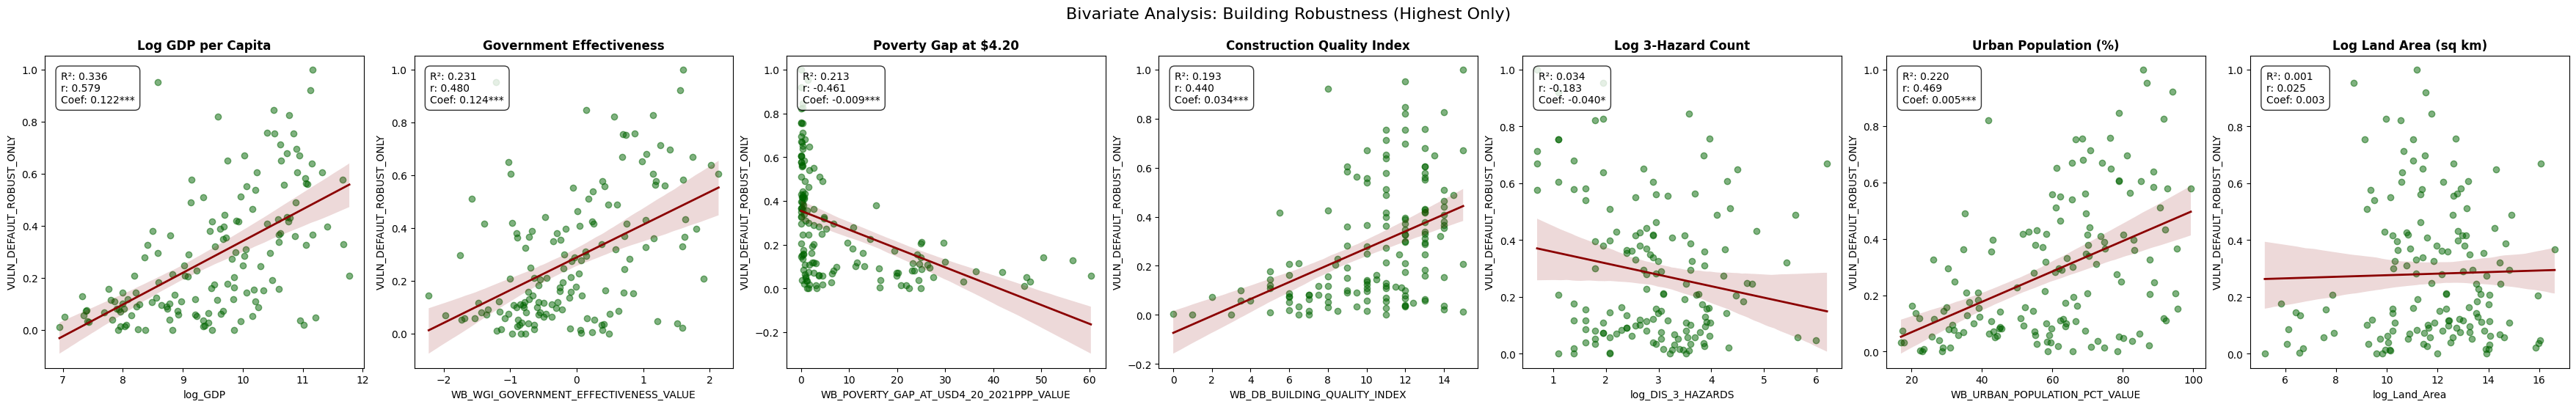

| IV                         | Coef       |   R-squared |   P-value |
|:---------------------------|:-----------|------------:|----------:|
| Log GDP per Capita         | 0.1220***  |      0.3358 |    0      |
| Government Effectiveness   | 0.1240***  |      0.2307 |    0      |
| Poverty Gap at $4.20       | -0.0086*** |      0.2127 |    0      |
| Construction Quality Index | 0.0345***  |      0.1934 |    0      |
| Log 3-Hazard Count         | -0.0402*   |      0.0337 |    0.0745 |
| Urban Population (%)       | 0.0054***  |      0.2201 |    0      |
| Log Land Area (sq km)      | 0.0028     |      0.0006 |    0.7428 |


In [42]:
# =============================================================================
# 3. CORRELATION ANALYSIS & BIVARIATE REGRESSION
# =============================================================================

# --- 3-1. Feature Engineering (Log Transformations & Composites) ---
# Ensuring variables are created on the fixed N=150 sample
df_analysis_sub = df_stats.copy()

# -----------------------------------------------------------------------------
# PART A: CORRELATION MATRIX (Academic Publication Format)
# -----------------------------------------------------------------------------

correlation_vars = [
    'VULN_DEFAULT_ROBUSTNESS', 'VULN_DEFAULT_ROBUST_ONLY',
    'WB_POVERTY_GAP_AT_USD4_20_2021PPP_VALUE', 'log_GDP',
    'WB_WGI_GOVERNMENT_EFFECTIVENESS_VALUE', 'WB_DB_BUILDING_QUALITY_INDEX',
    'log_DIS_3_HAZARDS',
    'WB_URBAN_POPULATION_PCT_VALUE',
    'log_Land_Area'
]

corr_labels_short = {
    'VULN_DEFAULT_ROBUSTNESS': '(1) Robustness(M/H)', 'VULN_DEFAULT_ROBUST_ONLY': '(2) Robustness(H)',
    'WB_POVERTY_GAP_AT_USD4_20_2021PPP_VALUE': '(3) Poverty Gap', 'log_GDP': '(4) Log GDP p.c.',
    'WB_WGI_GOVERNMENT_EFFECTIVENESS_VALUE': '(5) Gov. Effectiveness', 'WB_DB_BUILDING_QUALITY_INDEX': '(6) Building Quality',
    'log_DIS_EQK': '(7) Log EQK', 'log_DIS_STM': '(8) Log STM', 'log_DIS_FLD': '(9) Log FLD', 'log_DIS_3_HAZARDS': '(10) Log 3-Haz',
    'WB_URBAN_POPULATION_PCT_VALUE': '(11) Urban Pop %',
    'log_Land_Area': '(12) Log Land Area'
}

def get_formatted_corr_matrix(df, vars, labels, lower_only=True):
    n = len(vars)
    rho = df[vars].corr()
    pval = pd.DataFrame(np.zeros((n, n)), index=vars, columns=vars)
    for i in range(n):
        for j in range(n):
            if i != j:
                _, p = pearsonr(df[vars[i]], df[vars[j]])
                pval.iloc[i, j] = p

    def star_format(r, p):
        if p < 0.01: s = '***'
        elif p < 0.05: s = '**'
        elif p < 0.10: s = '*'
        else: s = ''
        return f"{r:.3f}{s}"

    formatted_df = pd.DataFrame(index=[labels[v] for v in vars], columns=[labels[v] for v in vars])
    for i in range(n):
        for j in range(n):
            if lower_only and i < j:
                formatted_df.iloc[i, j] = ""
            else:
                formatted_df.iloc[i, j] = star_format(rho.iloc[i, j], pval.iloc[i, j])
    return formatted_df

# Generate and Export Correlation Matrix
corr_matrix_pub = get_formatted_corr_matrix(df_analysis_sub, correlation_vars, corr_labels_short)
print("\n" + "="*80 + "\nCORRELATION MATRIX (Lower Triangle)\n" + "="*80)
print(corr_matrix_pub.to_string())
corr_matrix_pub.to_csv(RESULTS_DATA_FOLDER / "correlation_matrix_publication.csv")

# -----------------------------------------------------------------------------
# PART B: SINGLE REGRESSION & SCATTERPLOTS
# -----------------------------------------------------------------------------

iv_map = {
    'log_GDP': 'Log GDP per Capita',
    'WB_WGI_GOVERNMENT_EFFECTIVENESS_VALUE': 'Government Effectiveness',
    'WB_POVERTY_GAP_AT_USD4_20_2021PPP_VALUE': 'Poverty Gap at $4.20',
    'WB_DB_BUILDING_QUALITY_INDEX': 'Construction Quality Index',
    'log_DIS_3_HAZARDS': 'Log 3-Hazard Count',
    'WB_URBAN_POPULATION_PCT_VALUE': 'Urban Population (%)',
    'log_Land_Area': 'Log Land Area (sq km)'
}

dv_map = {
    'VULN_DEFAULT_ROBUSTNESS': 'Building Robustness (Medium/High)',
    'VULN_DEFAULT_ROBUST_ONLY': 'Building Robustness (Highest Only)'
}

def run_bivariate_analysis(df, dv_col, dv_label, iv_dict):
    n_ivs = len(iv_dict)
    fig, axes = plt.subplots(1, n_ivs, figsize=(n_ivs * 5, 5), constrained_layout=True)
    summary_list = []

    for i, (iv_col, iv_label) in enumerate(iv_dict.items()):
        # OLS Regression
        model = smf.ols(f"{dv_col} ~ {iv_col}", data=df).fit(cov_type='HC3')
        r2, p, coef = model.rsquared, model.pvalues[iv_col], model.params[iv_col]
        corr_r = df[dv_col].corr(df[iv_col])

        # Plotting
        ax = axes[i]
        sns.regplot(x=iv_col, y=dv_col, data=df, ax=ax,
                    scatter_kws={'alpha':0.5, 'color':'#006400'},
                    line_kws={'color':'darkred', 'lw':2})

        stars = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.1 else ''
        stats_text = f"R²: {r2:.3f}\nr: {corr_r:.3f}\nCoef: {coef:.3f}{stars}"
        ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, verticalalignment='top',
                bbox=dict(boxstyle="round,pad=0.5", fc="white", alpha=0.8))
        ax.set_title(f"{iv_label}", fontsize=12, fontweight='bold')

        summary_list.append({
            'IV': iv_label, 'Coef': f"{coef:.4f}{stars}", 'R-squared': round(r2, 4), 'P-value': round(p, 4)
        })

    plt.suptitle(f"Bivariate Analysis: {dv_label}", fontsize=16, y=1.08)
    plt.show()
    return pd.DataFrame(summary_list)

# Execution
for dv_key, dv_name in dv_map.items():
    print(f"\n--- Running Analysis for DV: {dv_name} ---")
    reg_summary = run_bivariate_analysis(df_analysis_sub, dv_key, dv_name, iv_map)
    print(reg_summary.to_markdown(index=False))



# Multiple regression

In [ ]:
# Check list of World Bank Region
unique_regions = df_stats['REGION'].unique()

# Print the list of unique regions
print(unique_regions)

['Sub-Saharan Africa' 'Europe & Central Asia' 'Middle East & North Africa'
 'Latin America & Caribbean' 'East Asia & Pacific' 'South Asia'
 'North America']


In [45]:
# -----------------------------------------------------------------------------
# 0. DATA PREPARATION AND PRE-PROCESSING
# -----------------------------------------------------------------------------
df_multi_regress = df_stats.copy()


# Mean Centering

vars_to_center_map = {
    'log_GDP': 'C_log_GDP',
    'WB_WGI_GOVERNMENT_EFFECTIVENESS_VALUE': 'C_CWGI',
    'WB_DB_BUILDING_QUALITY_INDEX': 'C_CDBQ',
    'WB_POVERTY_GAP_AT_USD4_20_2021PPP_VALUE': 'C_POVERTY',
    'WB_URBAN_POPULATION_PCT_VALUE': 'C_URBAN',
    'log_Land_Area': 'C_log_LAND',
    'log_DIS_EQK': 'C_log_DIS_EQK',
    'log_DIS_STM': 'C_log_DIS_STM',
    'log_DIS_EQK_STM': 'C_log_DIS_EQK_STM',
    'log_DIS_FLD': 'C_log_DIS_FLD',
    'log_DIS_3_HAZARDS': 'C_log_DIS_3_HAZARDS'
}

for raw_var, centered_var_name in vars_to_center_map.items():
    if raw_var in df_multi_regress.columns:
        df_multi_regress[centered_var_name] = df_multi_regress[raw_var] - df_multi_regress[raw_var].mean()

# poverty squared
df_multi_regress['C_POVERTY_SQ'] = df_multi_regress['C_POVERTY'] ** 2


# -----------------------------------------------------------------------------
#  VIF DIAGNOSTICS
# -----------------------------------------------------------------------------
print("\n" + "=" * 80)
print("VIF DIAGNOSTICS")
print("=" * 80)

vif_test_vars = ['C_log_LAND', 'C_URBAN', 'C_POVERTY', 'C_log_GDP', 'C_CWGI', 'C_CDBQ']
vif_data = df_multi_regress[vif_test_vars].dropna()

vif_results = pd.DataFrame()
vif_results["Variable"] = vif_test_vars
vif_results["VIF"] = [variance_inflation_factor(vif_data.values, i) for i in range(len(vif_test_vars))]
print(vif_results.to_string(index=False))


# -----------------------------------------------------------------------------
# 1. GENERIC OLS ANALYSIS FUNCTION
# -----------------------------------------------------------------------------

def run_ols_and_store(model_label: str, dependent_var: str, independent_vars: list, df: pd.DataFrame, fixed_effects: str = None):
    """Runs OLS regression with HC1 robust errors and returns the model object and metadata."""
    unique_vars = []
    [unique_vars.append(x) for x in independent_vars if x not in unique_vars]

    formula = f"{dependent_var} ~ {' + '.join(unique_vars)}"

    if fixed_effects:
        formula += f" + {fixed_effects}"
    try:
        model = smf.ols(formula=formula, data=df).fit(cov_type='HC1')
        return {
            'label': model_label,
            'model': model,
            'formula': formula,
            'DV': dependent_var,
        }

    except Exception as e:
        print(f"❌ WARNING: Model {model_label} failed. Details: {e}")
        return {'label': model_label, 'model': None, 'formula': formula, 'DV': dependent_var}

# -----------------------------------------------------------------------------
# 2. MODEL DEFINITION
# -----------------------------------------------------------------------------


all_models_results = []
REGION_FE = 'C(REGION)'

for dv_raw, dv_label in dependent_vars_list:
    print(f"\n>>> Running Optimized Nested Analysis for DV: {dv_label}")

    # --- BLOCK A: THE STRUCTURAL NESTED STEPS (Table 1 & 2 Focus) ---

    # Model 1: Baseline Context (Environment & Urbanization)
    m1_base = ['C_log_LAND', 'C_URBAN']

    # Horse Race Models (Step-by-Side comparison)
    m2_poverty = m1_base + ['C_POVERTY', 'C_POVERTY_SQ']
    m3_income  = m1_base + ['C_log_GDP']
    m4_gov     = m1_base + ['C_CWGI']
    m5_policy  = m1_base + ['C_CDBQ']

    # Model 6: Full Race (The Joint / Main Model)
    # This combines Poverty, GDP, Governance, and Policy
    m6_full = m1_base + ['C_POVERTY', 'C_POVERTY_SQ', 'C_log_GDP', 'C_CWGI', 'C_CDBQ']

    structural_steps = [
        (f"{dv_label}-M1.Base",    m1_base),
        (f"{dv_label}-M2.Poverty", m2_poverty),
        (f"{dv_label}-M3.Income",  m3_income),
        (f"{dv_label}-M4.Gov",     m4_gov),
        (f"{dv_label}-M5.Policy",  m5_policy),
        (f"{dv_label}-M6.Full",    m6_full)
    ]

    for label, vars_list in structural_steps:
        all_models_results.append(run_ols_and_store(label, dv_raw, vars_list, df_multi_regress, fixed_effects=REGION_FE))

    # --- BLOCK B: DISASTER EXPOSURE & INTERACTIONS (Table 3 & Appendix Focus) ---
    # We build these on top of Model 6 (The Full Socio-Economic Context)

    for dis_name, c_disaster_var, char in disaster_vars_list:

        # Step 4: Disaster Main Effect (Learning vs. Depletion)
        m7_dis_main = m6_full + [c_disaster_var]
        all_models_results.append(run_ols_and_store(f"{dv_label}-{char}.7", dv_raw, m7_dis_main, df_multi_regress, fixed_effects=REGION_FE))

        # Step 5: Interactions (The "Robustness" Check)
        # Using the original RC adjusting vars: Poverty, GDP, WGI, BQCI
        for adj_name, c_adjust_var in adjusting_vars_list:
            # We add the interaction term to the disaster main model
            int_vars = m7_dis_main + [f'{c_adjust_var}:{c_disaster_var}']

            # Label based on previous convention (8-11)
            adj_code = {"Poverty": "8", "GDP": "9", "Governance": "10", "Building Reg.": "11"}[adj_name]
            all_models_results.append(run_ols_and_store(f"{dv_label}-{char}.{adj_code}", dv_raw, int_vars, df_multi_regress, fixed_effects=REGION_FE))

print(f"\n✅ All {len(all_models_results)} models completed. (Full Matrix + Nested Steps)")

# -----------------------------------------------------------------------------
# 4. VARIABLE LABELS AND FORMATTING
# -----------------------------------------------------------------------------

region_labels = {f'C(REGION)[T.{region_name}]': f'Region FE: {region_name}' for region_name in df_multi_regress['REGION'].unique()}

variable_map_en = {
    'Intercept': 'Constant',
    'C_log_LAND': 'Log Land Area',
    'C_URBAN': 'Urban Population %',
    'C_POVERTY': 'Poverty Gap ($4.20/day)',
    'C_POVERTY_SQ': 'Poverty Gap Squared',
    'C_log_GDP': 'Log GDP per Capita (PPP)',
    'C_CWGI': 'Government Effectiveness (WGI)',
    'C_CDBQ': 'Building Quality Index',
    'C_log_DIS_EQK': 'Earthquake Count (Log)',
    'C_log_DIS_STM': 'Storm Count (Log)',
    'C_log_DIS_FLD': 'Flood Count (Log)',
    'C_log_DIS_EQK_STM': 'Earthquake + Storm (Log)',
    'C_log_DIS_3_HAZARDS': '3 Hazards Combined (Log)',

    'C_POVERTY:C_log_DIS_EQK': 'Poverty × Earthquake',
    'C_POVERTY:C_log_DIS_STM': 'Poverty × Storm',
    'C_POVERTY:C_log_DIS_FLD': 'Poverty × Flood',
    'C_POVERTY:C_log_DIS_EQK_STM': 'Poverty × EQK+STM',
    'C_POVERTY:C_log_DIS_3_HAZARDS': 'Poverty × 3 Hazards',

    'C_log_DIS_EQK:C_log_GDP': 'GDP × Earthquake',
    'C_log_DIS_STM:C_log_GDP': 'GDP × Storm',
    'C_log_DIS_FLD:C_log_GDP': 'GDP × Flood',
    'C_log_DIS_EQK_STM:C_log_GDP': 'GDP × EQK+STM',
    'C_log_GDP:C_log_DIS_3_HAZARDS': 'GDP × 3 Hazards',

    'C_CWGI:C_log_DIS_EQK': 'Gov. Effectiveness × Earthquake',
    'C_CWGI:C_log_DIS_STM': 'Gov. Effectiveness × Storm',
    'C_CWGI:C_log_DIS_FLD': 'Gov. Effectiveness × Flood',
    'C_CWGI:C_log_DIS_EQK_STM': 'Gov. Effectiveness × EQK+STM',
    'C_CWGI:{CENTERED_3_HAZARDS_NAME}': 'Gov. Effectiveness × 3 Hazards',

    'C_CDBQ:C_log_DIS_EQK': 'Building Quality × Earthquake',
    'C_CDBQ:C_log_DIS_STM': 'Building Quality × Storm',
    'C_CDBQ:C_log_DIS_FLD': 'Building Quality × Flood',
    'C_CDBQ:C_log_DIS_EQK_STM': 'Building Quality × EQK+STM',
    'C_CDBQ:C_log_DIS_3_HAZARDS': 'Building Quality × 3 Hazards',

    **region_labels
}

info_dict = {
    'R-squared': lambda x: f'{x.rsquared:.4f}',
    'Adj. R-squared': lambda x: f'{x.rsquared_adj:.4f}',
    'Observations': lambda x: f'{int(x.nobs)}',
    'Region Fixed Effects': lambda x: 'Yes' if 'C(REGION)' in x.model.formula else 'No'
}

# -----------------------------------------------------------------------------
# 4. ORGANIZE AND EXPORT RESULTS
# -----------------------------------------------------------------------------

successful_results = [res for res in all_models_results if res['model'] is not None]
results_by_dv = {}
for dv_raw, _ in dependent_vars_list:
    results_by_dv[dv_raw] = [res for res in successful_results if res['DV'] == dv_raw]




VIF DIAGNOSTICS
  Variable      VIF
C_log_LAND 1.408791
   C_URBAN 2.112577
 C_POVERTY 2.573759
 C_log_GDP 6.338324
    C_CWGI 3.017643
    C_CDBQ 1.486520

>>> Running Optimized Nested Analysis for DV: VULN

>>> Running Optimized Nested Analysis for DV: ONLY

✅ All 62 models completed. (Full Matrix + Nested Steps)


In [46]:
#  EXPORT  REGRESSION RESULTS

# -----------------------------------------------------------------------------
# 1. EXCEL Export
# -----------------------------------------------------------------------------

def export_to_excel_formatted(results_by_dv, variable_map_en, export_path):
    from openpyxl import Workbook
    from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
    from openpyxl.utils.dataframe import dataframe_to_rows

    wb = Workbook()
    wb.remove(wb.active)

    # Style
    header_fill = PatternFill(start_color="366092", end_color="366092", fill_type="solid")
    header_font = Font(bold=True, color="FFFFFF", size=11)
    sig_fill_001 = PatternFill(start_color="C6EFCE", end_color="C6EFCE", fill_type="solid")  # 0.01
    sig_fill_005 = PatternFill(start_color="FFEB9C", end_color="FFEB9C", fill_type="solid")  # 0.05
    sig_fill_010 = PatternFill(start_color="FFC7CE", end_color="FFC7CE", fill_type="solid")  # 0.10
    thin_border = Border(
        left=Side(style='thin'), right=Side(style='thin'),
        top=Side(style='thin'), bottom=Side(style='thin')
    )

    dv_sheet_names = {
        'VULN_DEFAULT_ROBUSTNESS': 'Composite Vulnerability',
        'VULN_DEFAULT_ROBUST_ONLY': 'Robustness Only',
        'VULN_EARTHQUAKE_ROBUSTNESS': 'EQK Robustness Total',
        'VULN_EARTHQUAKE_ROBUST_ONLY': 'EQK Robustness Only',
        'VULN_WIND_ROBUSTNESS': 'Wind Robustness Total',
        'VULN_WIND_ROBUST_ONLY': 'Wind Robustness Only',
    }

    for dv, sheet_name in dv_sheet_names.items():
        if dv not in results_by_dv or not results_by_dv[dv]:
            continue

        ws = wb.create_sheet(title=sheet_name[:31])
        results_list = results_by_dv[dv]

        # Data frame creation
        data_rows = []
        model_labels = []

        for res in results_list:
            if res['model'] is None:
                continue
            model = res['model']
            label = res['label']
            model_labels.append(label)

            # get vars
            for var in model.params.index:
                var_display = variable_map_en.get(var, var)
                coef = model.params[var]
                se = model.bse[var]
                pval = model.pvalues[var]

                stars = ''
                if pval < 0.01:
                    stars = '***'
                elif pval < 0.05:
                    stars = '**'
                elif pval < 0.10:
                    stars = '*'

                data_rows.append({
                    'Model': label,
                    'Variable': var_display,
                    'Coefficient': coef,
                    'Std. Error': se,
                    'P-Value': pval,
                    'Sig.': stars,
                    't-stat': coef / se if se != 0 else np.nan
                })

            data_rows.append({
                'Model': label, 'Variable': 'R-squared',
                'Coefficient': model.rsquared, 'Std. Error': '', 'P-Value': '', 'Sig.': '', 't-stat': ''
            })
            data_rows.append({
                'Model': label, 'Variable': 'Adj. R-squared',
                'Coefficient': model.rsquared_adj, 'Std. Error': '', 'P-Value': '', 'Sig.': '', 't-stat': ''
            })
            data_rows.append({
                'Model': label, 'Variable': 'Observations',
                'Coefficient': int(model.nobs), 'Std. Error': '', 'P-Value': '', 'Sig.': '', 't-stat': ''
            })

        df_export = pd.DataFrame(data_rows)

        ws.append(['Dependent Variable: ' + sheet_name])
        ws.append(['Estimation Method: OLS with HC1 Robust Standard Errors'])
        ws.append(['Significance: * p<0.10, ** p<0.05, *** p<0.01'])
        ws.append([])

        for r_idx, row in enumerate(dataframe_to_rows(df_export, index=False, header=True), start=5):
            ws.append(row)

            if r_idx == 5:
                for cell in ws[r_idx]:
                    cell.fill = header_fill
                    cell.font = header_font
                    cell.alignment = Alignment(horizontal='center', vertical='center')
            else:
                if len(row) > 4 and isinstance(row[4], (int, float)):
                    pval = row[4]
                    for cell in ws[r_idx]:
                        if pval < 0.01:
                            cell.fill = sig_fill_001
                        elif pval < 0.05:
                            cell.fill = sig_fill_005
                        elif pval < 0.10:
                            cell.fill = sig_fill_010

                for cell in ws[r_idx]:
                    cell.border = thin_border
                    cell.alignment = Alignment(horizontal='left', vertical='center')

        ws.column_dimensions['A'].width = 15
        ws.column_dimensions['B'].width = 35
        ws.column_dimensions['C'].width = 12
        ws.column_dimensions['D'].width = 12
        ws.column_dimensions['E'].width = 10
        ws.column_dimensions['F'].width = 8
        ws.column_dimensions['G'].width = 10

    try:
        wb.save(export_path)
        print(f"Complete Export as Excel: {export_path}")
        return True
    except Exception as e:
        print(f"Excel Export Error: {e}")
        return False


# -----------------------------------------------------------------------------
# 2. Export as HTML
# -----------------------------------------------------------------------------

def export_to_html(results_by_dv, variable_map_en, export_path):
    html_content = """
    <!DOCTYPE html>
    <html>
    <head>
        <meta charset="UTF-8">
        <title>Regression Results</title>
        <style>
            body { font-family: Arial, sans-serif; margin: 20px; background-color: #f5f5f5; }
            h1 { color: #2c3e50; border-bottom: 3px solid #3498db; padding-bottom: 10px; }
            h2 { color: #34495e; margin-top: 30px; }
            table { border-collapse: collapse; width: 100%; margin: 20px 0; background-color: white; box-shadow: 0 2px 4px rgba(0,0,0,0.1); }
            th { background-color: #3498db; color: white; padding: 12px; text-align: left; font-weight: bold; }
            td { padding: 10px; border-bottom: 1px solid #ddd; }
            tr:hover { background-color: #f1f1f1; }
            .sig-001 { background-color: #d4edda; }
            .sig-005 { background-color: #fff3cd; }
            .sig-010 { background-color: #f8d7da; }
            .info-row { background-color: #e9ecef; font-weight: bold; }
            .number { text-align: right; font-family: 'Courier New', monospace; }
        </style>
    </head>
    <body>
        <h1>Regression Analysis Results</h1>
        <p><strong>Estimation Method:</strong> OLS with HC1 Robust Standard Errors</p>
        <p><strong>Significance Levels:</strong> <span class="sig-010">* p&lt;0.10</span>, <span class="sig-005">** p&lt;0.05</span>, <span class="sig-001">*** p&lt;0.01</span></p>
    """

    dv_titles = {
        'VULN_DEFAULT_ROBUSTNESS': 'Composite Building Vulnerability Index',
        'VULN_DEFAULT_ROBUST_ONLY': 'Building Robustness ONLY Index',
        'VULN_EARTHQUAKE_ROBUSTNESS': 'Earthquake Robustness (Total Score)',
        'VULN_EARTHQUAKE_ROBUST_ONLY': 'Earthquake Robustness (ONLY Score)',
        'VULN_WIND_ROBUSTNESS': 'Wind/Storm Robustness (Total Score)',
        'VULN_WIND_ROBUST_ONLY': 'Wind/Storm Robustness (ONLY Score)',
    }

    for dv, title in dv_titles.items():
        if dv not in results_by_dv or not results_by_dv[dv]:
            continue

        html_content += f"\n<h2>Dependent Variable: {title}</h2>\n"
        html_content += "<table>\n<thead><tr><th>Variable</th>"

        results_list = results_by_dv[dv]
        model_labels = [res['label'] for res in results_list if res['model']]

        for label in model_labels:
            html_content += f"<th>{label}</th>"
        html_content += "</tr></thead>\n<tbody>\n"

        # Craete var lis
        all_vars = []
        for res in results_list:
            if res['model']:
                all_vars.extend([v for v in res['model'].params.index if v not in all_vars])

        # Get coefficient
        for var in all_vars:
            var_display = variable_map_en.get(var, var)
            html_content += f"<tr><td><strong>{var_display}</strong></td>"

            for res in results_list:
                if res['model'] is None or var not in res['model'].params.index:
                    html_content += "<td class='number'>-</td>"
                    continue

                model = res['model']
                coef = model.params[var]
                se = model.bse[var]
                pval = model.pvalues[var]

                stars = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.10 else ''
                css_class = 'sig-001' if pval < 0.01 else 'sig-005' if pval < 0.05 else 'sig-010' if pval < 0.10 else ''

                html_content += f"<td class='number {css_class}'>{coef:.4f}{stars}<br><small>({se:.4f})</small></td>"

            html_content += "</tr>\n"

        # R2
        for stat_name in ['R-squared', 'Adj. R-squared', 'Observations']:
            html_content += f"<tr class='info-row'><td><strong>{stat_name}</strong></td>"
            for res in results_list:
                if res['model'] is None:
                    html_content += "<td>-</td>"
                    continue
                model = res['model']
                if stat_name == 'R-squared':
                    val = f"{model.rsquared:.4f}"
                elif stat_name == 'Adj. R-squared':
                    val = f"{model.rsquared_adj:.4f}"
                else:
                    val = f"{int(model.nobs)}"
                html_content += f"<td class='number'>{val}</td>"
            html_content += "</tr>\n"

        html_content += "</tbody>\n</table>\n"

    html_content += "\n</body>\n</html>"

    try:
        with open(export_path, 'w', encoding='utf-8') as f:
            f.write(html_content)
        print(f"Complete Exort as HTML: {export_path}")
        return True
    except Exception as e:
        print(f"HTML Export Error: {e}")
        return False



# -----------------------------------------------------------------------------
# 4. Run
# -----------------------------------------------------------------------------

base_path = os.path.join(RESULTS_DATA_FOLDER, "regression_results")

# 1. Excel
excel_path = base_path + "_formatted.xlsx"
export_to_excel_formatted(results_by_dv, variable_map_en, excel_path)

# 2. HTML
html_path = base_path + "_report.html"
export_to_html(results_by_dv, variable_map_en, html_path)



print("\n" + "=" * 80)
print("Export Completed")
print(f"   Excel: {excel_path}")
print(f"   HTML:  {html_path}")
print("=" * 80)

Complete Export as Excel: /content/drive/MyDrive/Resilient_Housing_Global_Regression/Results/regression_results_formatted.xlsx
Complete Exort as HTML: /content/drive/MyDrive/Resilient_Housing_Global_Regression/Results/regression_results_report.html

Export Completed
   Excel: /content/drive/MyDrive/Resilient_Housing_Global_Regression/Results/regression_results_formatted.xlsx
   HTML:  /content/drive/MyDrive/Resilient_Housing_Global_Regression/Results/regression_results_report.html


# Robustness Check  -

In [ ]:
# =============================================================================
# COMPREHENSIVE ROBUSTNESS CHECKS - COMPLETE VERSION
# All RCs include: Spec A (GDP) × DV (VULN, ONLY) + Spec B (Inst.) × DV (VULN, ONLY)
# =============================================================================

# --- A. INITIAL SETUP ---
robustness_models = []

# Ensure REGION is categorical
if 'REGION' in df_multi_regress.columns:
    df_multi_regress['REGION'] = df_multi_regress['REGION'].astype('category')
    print("\n✅ 'REGION' variable converted to categorical type for fixed effects.")
else:
    print("\n🛑 CRITICAL WARNING: 'REGION' column not found. Fixed effects will fail.")

# Define the fixed effect term
FE_TERM = " + C(REGION)"

# --- B. VARIABLE PREPARATION ---
print("\n" + "="*80)
print("VARIABLE PREPARATION FOR ROBUSTNESS CHECKS")
print("="*80)

try:
    print("\n[Prep] Coercing columns to numeric...")
    COLS_TO_CLEAN = [
        'MPI_HOUSING', 'DIS_EQK_DEATHS', 'DIS_STM_DEATHS', 'DIS_FLD_DEATHS',
        'WB_POVERTY_HC_RATIO_AT_USD4_20_VALUE', 'WB_POVERTY_GAP_AT_USD4_20_2021PPP_VALUE',
        'WB_POVERTY_GAP_AT_USD3_00_2021PPP_VALUE','WB_POVERTY_GAP_AT_USD8_30_2021PPP_VALUE',
        'WB_POPULATION_TOTAL_VALUE', 'WB_GDP_PCAP_PPP_INTL_2021_VALUE',
        'WB_WGI_GOVERNMENT_EFFECTIVENESS_VALUE', 'WB_DB_BUILDING_QUALITY_INDEX',
        'VULN_DEFAULT_ROBUST_ONLY', 'VULN_DEFAULT_ROBUSTNESS',
        'DIS_EQK', 'DIS_STM', 'DIS_FLD', 'DIS_3_HAZARDS',
        'DIS_EQK_DEATHS', 'DIS_FLD_DEATHS', 'DIS_STM_DEATHS',
        'VULN_DEFAULT_ROBUST_ONLY_WD', 'VULN_DEFAULT_ROBUSTNESS_WD'
    ]
    for col in COLS_TO_CLEAN:
        if col in df_multi_regress.columns:
            df_multi_regress[col] = pd.to_numeric(df_multi_regress[col], errors='coerce')
    print("✅ Numeric conversion complete.")

    print("[Prep] Creating centered and transformed variables...")
    # Core variables
    df_multi_regress['C_POVERTY'] = df_multi_regress['WB_POVERTY_GAP_AT_USD4_20_2021PPP_VALUE'] - df_multi_regress['WB_POVERTY_GAP_AT_USD4_20_2021PPP_VALUE'].mean()
    df_multi_regress['log_GDP'] = np.log(df_multi_regress['WB_GDP_PCAP_PPP_INTL_2021_VALUE'])
    df_multi_regress['C_log_GDP'] = df_multi_regress['log_GDP'] - df_multi_regress['log_GDP'].mean()
    df_multi_regress['C_GOV_EFF'] = df_multi_regress['WB_WGI_GOVERNMENT_EFFECTIVENESS_VALUE'] - df_multi_regress['WB_WGI_GOVERNMENT_EFFECTIVENESS_VALUE'].mean()
    df_multi_regress['C_CDBQ'] = df_multi_regress['WB_DB_BUILDING_QUALITY_INDEX'] - df_multi_regress['WB_DB_BUILDING_QUALITY_INDEX'].mean()

    # Hazard variables
    HAZARDS = ['DIS_EQK', 'DIS_STM','DIS_FLD', 'DIS_3_HAZARDS','DIS_EQK_DEATHS', 'DIS_FLD_DEATHS', 'DIS_STM_DEATHS']
    for hazard in HAZARDS:
        df_multi_regress[f'log_{hazard}'] = np.log1p(df_multi_regress[hazard])
        df_multi_regress[f'C_log_{hazard}'] = df_multi_regress[f'log_{hazard}'] - df_multi_regress[f'log_{hazard}'].mean()

    # Alternative Dependent Variable
    df_multi_regress['ROB_MPI_HOUSING'] = 100 - df_multi_regress['MPI_HOUSING']
    print("✅ Variable preparation complete.")

except KeyError as e:
    print(f"🛑 CRITICAL WARNING: Missing column: {e}. Please ensure all original data variables are loaded.")

# --- C. DEFINE MODEL SPECIFICATIONS ---
# Specification A: Economic Model (GDP-focused)
SPEC_A_VARS = "C_log_GDP + C_log_DIS_EQK + C_log_DIS_STM + C_log_DIS_FLD"
# Specification B: Institutional Model (Governance-focused)
SPEC_B_VARS = "C_GOV_EFF + C_CDBQ + C_log_DIS_EQK + C_log_DIS_STM + C_log_DIS_FLD"



# --- D. ROBUSTNESS CHECKS ---

# =============================================================================
# RC0: Baseline (4 models)
# =============================================================================
print("\n[RC0] Baseline model...")

# RC0-A-VULN
robustness_models.append({'label': 'RC0-A-VULN', 'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS ~ C_POVERTY + {SPEC_A_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'VULN-Baseline (GDP Model)'})
# RC0-A-ONLY
robustness_models.append({'label': 'RC0-A-ONLY', 'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY ~ C_POVERTY + {SPEC_A_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'ONLY-Baseline  (GDP Model)'})
# RC0-B-VULN
robustness_models.append({'label': 'RC0-B-VULN', 'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS ~ C_POVERTY + {SPEC_B_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'VULN-Baseline  (Inst. Model)'})
# RC0-B-ONLY
robustness_models.append({'label': 'RC0-B-ONLY', 'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY ~ C_POVERTY + {SPEC_B_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'ONLY-Baseline  (Inst. Model)'})
print(f"✅ RC0 complete: 4 models estimated")




# =============================================================================
# RC1: ALTERNATIVE POVERTY - QUARTILES (4 models)
# =============================================================================
print("\n[RC1] Running: Alternative Poverty (Quartiles)...")
poverty_quantiles = df_multi_regress['WB_POVERTY_GAP_AT_USD4_20_2021PPP_VALUE'].quantile([0.25, 0.50, 0.75])
df_multi_regress['Poverty_Q2'] = ((df_multi_regress['WB_POVERTY_GAP_AT_USD4_20_2021PPP_VALUE'] > poverty_quantiles[0.25]) & (df_multi_regress['WB_POVERTY_GAP_AT_USD4_20_2021PPP_VALUE'] <= poverty_quantiles[0.50])).astype(int)
df_multi_regress['Poverty_Q3'] = ((df_multi_regress['WB_POVERTY_GAP_AT_USD4_20_2021PPP_VALUE'] > poverty_quantiles[0.50]) & (df_multi_regress['WB_POVERTY_GAP_AT_USD4_20_2021PPP_VALUE'] <= poverty_quantiles[0.75])).astype(int)
df_multi_regress['Poverty_Q4'] = (df_multi_regress['WB_POVERTY_GAP_AT_USD4_20_2021PPP_VALUE'] > poverty_quantiles[0.75]).astype(int)
POV_QUARTILE_VARS = "Poverty_Q2 + Poverty_Q3 + Poverty_Q4"

# RC1-A-VULN
robustness_models.append({'label': 'RC1-A-VULN', 'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS ~ {POV_QUARTILE_VARS} + {SPEC_A_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'VULN-Poverty Quartiles (GDP Model)'})
# RC1-A-ONLY
robustness_models.append({'label': 'RC1-A-ONLY', 'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY ~ {POV_QUARTILE_VARS} + {SPEC_A_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'ONLY-Poverty Quartiles (GDP Model)'})
# RC1-B-VULN
robustness_models.append({'label': 'RC1-B-VULN', 'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS ~ {POV_QUARTILE_VARS} + {SPEC_B_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'VULN-Poverty Quartiles (Inst. Model)'})
# RC1-B-ONLY
robustness_models.append({'label': 'RC1-B-ONLY', 'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY ~ {POV_QUARTILE_VARS} + {SPEC_B_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'ONLY-Poverty Quartiles (Inst. Model)'})
print(f"✅ RC1 complete: 4 models estimated")

# =============================================================================
# RC2: ALTERNATIVE POVERTY - HEADCOUNT ($4.20) (4 models)
# =============================================================================
print("\n[RC2] Running: Alternative Poverty (Headcount $4.20)...")
if 'WB_POVERTY_HC_RATIO_AT_USD4_20_VALUE' in df_multi_regress.columns:
    df_multi_regress['C_POVERTY_420'] = df_multi_regress['WB_POVERTY_HC_RATIO_AT_USD4_20_VALUE'] - df_multi_regress['WB_POVERTY_HC_RATIO_AT_USD4_20_VALUE'].mean()

    # RC2-A-VULN
    robustness_models.append({'label': 'RC2-A-VULN', 'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS ~ C_POVERTY_420 + {SPEC_A_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'VULN-Poverty HC $4.20 (GDP Model)'})
    # RC2-A-ONLY
    robustness_models.append({'label': 'RC2-A-ONLY', 'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY ~ C_POVERTY_420 + {SPEC_A_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'ONLY-Poverty HC $4.20 (GDP Model)'})
    # RC2-B-VULN
    robustness_models.append({'label': 'RC2-B-VULN', 'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS ~ C_POVERTY_420 + {SPEC_B_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'VULN-Poverty HC $4.20 (Inst. Model)'})
    # RC2-B-ONLY
    robustness_models.append({'label': 'RC2-B-ONLY', 'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY ~ C_POVERTY_420 + {SPEC_B_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'ONLY-Poverty HC $4.20 (Inst. Model)'})
    print(f"✅ RC2 complete: 4 models estimated")
else:
    print("⚠️ RC2 skipped: Poverty headcount data not available.")

# =============================================================================
# RC3: ALTERNATIVE POVERTY - GAP ($3.00) (4 models)
# =============================================================================
print("\n[RC3] Running: Alternative Poverty (Gap $3.00)...")
if 'WB_POVERTY_GAP_AT_USD3_00_2021PPP_VALUE' in df_multi_regress.columns:
    df_multi_regress['C_POVERTY_300'] = df_multi_regress['WB_POVERTY_GAP_AT_USD3_00_2021PPP_VALUE'] - df_multi_regress['WB_POVERTY_GAP_AT_USD3_00_2021PPP_VALUE'].mean()

    # RC3-A-VULN
    robustness_models.append({'label': 'RC3-A-VULN', 'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS ~ C_POVERTY_300 + {SPEC_A_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'VULN-Poverty Gap $3.00 (GDP Model)'})
    # RC3-A-ONLY
    robustness_models.append({'label': 'RC3-A-ONLY', 'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY ~ C_POVERTY_300 + {SPEC_A_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'ONLY-Poverty Gap $3.00 (GDP Model)'})
    # RC3-B-VULN
    robustness_models.append({'label': 'RC3-B-VULN', 'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS ~ C_POVERTY_300 + {SPEC_B_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'VULN-Poverty Gap $3.00 (Inst. Model)'})
    # RC3-B-ONLY
    robustness_models.append({'label': 'RC3-B-ONLY', 'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY ~ C_POVERTY_300 + {SPEC_B_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'ONLY-Poverty Gap $3.00 (Inst. Model)'})
    print(f"✅ RC3 complete: 4 models estimated")
else:
    print("⚠️ RC3 skipped: Poverty gap $3.00 data not available.")

# =============================================================================
# RC4: ALTERNATIVE POVERTY - GAP ($8.30) (4 models)
# =============================================================================
print("\n[RC4] Running: Alternative Poverty (Gap $8.30)...")
if 'WB_POVERTY_GAP_AT_USD8_30_2021PPP_VALUE' in df_multi_regress.columns:
    df_multi_regress['C_POVERTY_830'] = df_multi_regress['WB_POVERTY_GAP_AT_USD8_30_2021PPP_VALUE'] - df_multi_regress['WB_POVERTY_GAP_AT_USD8_30_2021PPP_VALUE'].mean()

    # RC4-A-VULN
    robustness_models.append({'label': 'RC4-A-VULN', 'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS ~ C_POVERTY_830 + {SPEC_A_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'VULN-Poverty Gap $8.30 (GDP Model)'})
    # RC4-A-ONLY
    robustness_models.append({'label': 'RC4-A-ONLY', 'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY ~ C_POVERTY_830 + {SPEC_A_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'ONLY-Poverty Gap $8.30 (GDP Model)'})
    # RC4-B-VULN
    robustness_models.append({'label': 'RC4-B-VULN', 'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS ~ C_POVERTY_830 + {SPEC_B_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'VULN-Poverty Gap $8.30 (Inst. Model)'})
    # RC4-B-ONLY
    robustness_models.append({'label': 'RC4-B-ONLY', 'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY ~ C_POVERTY_830 + {SPEC_B_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'ONLY-Poverty Gap $8.30 (Inst. Model)'})
    print(f"✅ RC4 complete: 4 models estimated")
else:
    print("⚠️ RC4 skipped: Poverty gap $8.30 data not available.")

# =============================================================================
# RC5: SAMPLE RESTRICTION - EXCLUDE SMALL STATES (4 models)
# =============================================================================
print("\n[RC5] Running: Sample Restriction (Exclude Small States)...")
if 'WB_POPULATION_TOTAL_VALUE' in df_multi_regress.columns:
    df_large = df_multi_regress[df_multi_regress['WB_POPULATION_TOTAL_VALUE'] > 1500000].copy()

    # RC5-A-VULN
    robustness_models.append({'label': 'RC5-A-VULN', 'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS ~ C_POVERTY + {SPEC_A_VARS}{FE_TERM}", data=df_large).fit(cov_type='HC1'), 'description': f'VULN-Exclude Small States (GDP, n={len(df_large)})'})
    # RC5-A-ONLY
    robustness_models.append({'label': 'RC5-A-ONLY', 'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY ~ C_POVERTY + {SPEC_A_VARS}{FE_TERM}", data=df_large).fit(cov_type='HC1'), 'description': f'ONLY-Exclude Small States (GDP, n={len(df_large)})'})
    # RC5-B-VULN
    robustness_models.append({'label': 'RC5-B-VULN', 'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS ~ C_POVERTY + {SPEC_B_VARS}{FE_TERM}", data=df_large).fit(cov_type='HC1'), 'description': f'VULN-Exclude Small States (Inst., n={len(df_large)})'})
    # RC5-B-ONLY
    robustness_models.append({'label': 'RC5-B-ONLY', 'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY ~ C_POVERTY + {SPEC_B_VARS}{FE_TERM}", data=df_large).fit(cov_type='HC1'), 'description': f'ONLY-Exclude Small States (Inst., n={len(df_large)})'})
    print(f"✅ RC5 complete: 4 models estimated")
else:
    print("⚠️ RC5 skipped: Population data not available.")

# =============================================================================
# RC6 & RC7: SAMPLE RESTRICTION - INCOME GROUPS (8 models total)
# =============================================================================
print("\n[RC6 & RC7] Running: Sample Restriction (Income Groups)...")
median_gdp = df_multi_regress['WB_GDP_PCAP_PPP_INTL_2021_VALUE'].median()
df_low_income = df_multi_regress[df_multi_regress['WB_GDP_PCAP_PPP_INTL_2021_VALUE'] < median_gdp].copy()
df_high_income = df_multi_regress[df_multi_regress['WB_GDP_PCAP_PPP_INTL_2021_VALUE'] >= median_gdp].copy()

# Re-center variables for sub-samples
for df_sub in [df_low_income, df_high_income]:
    df_sub['C_POVERTY_sub'] = df_sub['WB_POVERTY_GAP_AT_USD4_20_2021PPP_VALUE'] - df_sub['WB_POVERTY_GAP_AT_USD4_20_2021PPP_VALUE'].mean()
    df_sub['C_log_GDP_sub'] = np.log(df_sub['WB_GDP_PCAP_PPP_INTL_2021_VALUE']) - np.log(df_sub['WB_GDP_PCAP_PPP_INTL_2021_VALUE']).mean()
    df_sub['C_GOV_EFF_sub'] = df_sub['WB_WGI_GOVERNMENT_EFFECTIVENESS_VALUE'] - df_sub['WB_WGI_GOVERNMENT_EFFECTIVENESS_VALUE'].mean()
    df_sub['C_CDBQ_sub'] = df_sub['WB_DB_BUILDING_QUALITY_INDEX'] - df_sub['WB_DB_BUILDING_QUALITY_INDEX'].mean()

# --- RC6: Low/Lower-Middle Income (4 models) ---
# RC6-A-VULN
robustness_models.append({'label': 'RC6-A-VULN', 'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS ~ C_POVERTY_sub + C_log_GDP_sub + C_log_DIS_EQK + C_log_DIS_STM + C_log_DIS_FLD{FE_TERM}", data=df_low_income).fit(cov_type='HC1'), 'description': f'VULN-Low/Lower-Middle Income (GDP, n={len(df_low_income)})'})
# RC6-A-ONLY
robustness_models.append({'label': 'RC6-A-ONLY', 'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY ~ C_POVERTY_sub + C_log_GDP_sub + C_log_DIS_EQK + C_log_DIS_STM + C_log_DIS_FLD{FE_TERM}", data=df_low_income).fit(cov_type='HC1'), 'description': f'ONLY-Low/Lower-Middle Income (GDP, n={len(df_low_income)})'})
# RC6-B-VULN
robustness_models.append({'label': 'RC6-B-VULN', 'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS ~ C_POVERTY_sub + C_GOV_EFF_sub + C_CDBQ_sub + C_log_DIS_EQK + C_log_DIS_STM + C_log_DIS_FLD{FE_TERM}", data=df_low_income).fit(cov_type='HC1'), 'description': f'VULN-Low/Lower-Middle Income (Inst., n={len(df_low_income)})'})
# RC6-B-ONLY
robustness_models.append({'label': 'RC6-B-ONLY', 'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY ~ C_POVERTY_sub + C_GOV_EFF_sub + C_CDBQ_sub + C_log_DIS_EQK + C_log_DIS_STM + C_log_DIS_FLD{FE_TERM}", data=df_low_income).fit(cov_type='HC1'), 'description': f'ONLY-Low/Lower-Middle Income (Inst., n={len(df_low_income)})'})

# --- RC7: Upper-Middle/High Income (4 models) ---
# RC7-A-VULN
robustness_models.append({'label': 'RC7-A-VULN', 'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS ~ C_POVERTY_sub + C_log_GDP_sub + C_log_DIS_EQK + C_log_DIS_STM + C_log_DIS_FLD{FE_TERM}", data=df_high_income).fit(cov_type='HC1'), 'description': f'VULN-Upper-Middle/High Income (GDP, n={len(df_high_income)})'})
# RC7-A-ONLY
robustness_models.append({'label': 'RC7-A-ONLY', 'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY ~ C_POVERTY_sub + C_log_GDP_sub + C_log_DIS_EQK + C_log_DIS_STM + C_log_DIS_FLD{FE_TERM}", data=df_high_income).fit(cov_type='HC1'), 'description': f'ONLY-Upper-Middle/High Income (GDP, n={len(df_high_income)})'})
# RC7-B-VULN
robustness_models.append({'label': 'RC7-B-VULN', 'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS ~ C_POVERTY_sub + C_GOV_EFF_sub + C_CDBQ_sub + C_log_DIS_EQK + C_log_DIS_STM + C_log_DIS_FLD{FE_TERM}", data=df_high_income).fit(cov_type='HC1'), 'description': f'VULN-Upper-Middle/High Income (Inst., n={len(df_high_income)})'})
# RC7-B-ONLY
robustness_models.append({'label': 'RC7-B-ONLY', 'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY ~ C_POVERTY_sub + C_GOV_EFF_sub + C_CDBQ_sub + C_log_DIS_EQK + C_log_DIS_STM + C_log_DIS_FLD{FE_TERM}", data=df_high_income).fit(cov_type='HC1'), 'description': f'ONLY-Upper-Middle/High Income (Inst., n={len(df_high_income)})'})
print(f"✅ RC6 & RC7 complete: 8 models estimated")

# =============================================================================
# RC8: OUTLIER SENSITIVITY - EXCLUDE TOP 1% DISASTERS (4 models)
# =============================================================================
print("\n[RC8] Running: Outlier Sensitivity (Exclude Top 1% Disasters)...")
disaster_threshold = df_multi_regress['DIS_3_HAZARDS'].quantile(0.99)
df_no_outliers = df_multi_regress[df_multi_regress['DIS_3_HAZARDS'] < disaster_threshold].copy()

# RC8-A-VULN
robustness_models.append({'label': 'RC8-A-VULN', 'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS ~ C_POVERTY + {SPEC_A_VARS}{FE_TERM}", data=df_no_outliers).fit(cov_type='HC1'), 'description': f'VULN-Exclude Top 1% Disasters (GDP, n={len(df_no_outliers)})'})
# RC8-A-ONLY
robustness_models.append({'label': 'RC8-A-ONLY', 'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY ~ C_POVERTY + {SPEC_A_VARS}{FE_TERM}", data=df_no_outliers).fit(cov_type='HC1'), 'description': f'ONLY-Exclude Top 1% Disasters (GDP, n={len(df_no_outliers)})'})
# RC8-B-VULN
robustness_models.append({'label': 'RC8-B-VULN', 'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS ~ C_POVERTY + {SPEC_B_VARS}{FE_TERM}", data=df_no_outliers).fit(cov_type='HC1'), 'description': f'VULN-Exclude Top 1% Disasters (Inst., n={len(df_no_outliers)})'})
# RC8-B-ONLY
robustness_models.append({'label': 'RC8-B-ONLY', 'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY ~ C_POVERTY + {SPEC_B_VARS}{FE_TERM}", data=df_no_outliers).fit(cov_type='HC1'), 'description': f'ONLY-Exclude Top 1% Disasters (Inst., n={len(df_no_outliers)})'})
print(f"✅ RC8 complete: 4 models estimated")

# =============================================================================
# RC9: OUTLIER SENSITIVITY - WINSORIZE DISASTERS (P95) (4 models)
# =============================================================================
print("\n[RC9] Running: Outlier Sensitivity (Winsorize Disasters)...")
df_winsor = df_multi_regress.copy()
for hazard in ['DIS_EQK', 'DIS_STM', 'DIS_FLD']:
    p95 = df_winsor[hazard].quantile(0.95)
    df_winsor[hazard] = df_winsor[hazard].clip(upper=p95)
    df_winsor[f'log_{hazard}'] = np.log1p(df_winsor[hazard])
    df_winsor[f'C_log_{hazard}'] = df_winsor[f'log_{hazard}'] - df_winsor[f'log_{hazard}'].mean()

# RC9-A-VULN
robustness_models.append({'label': 'RC9-A-VULN', 'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS ~ C_POVERTY + {SPEC_A_VARS}{FE_TERM}", data=df_winsor).fit(cov_type='HC1'), 'description': 'VULN-Winsorized Disasters (GDP Model)'})
# RC9-A-ONLY
robustness_models.append({'label': 'RC9-A-ONLY', 'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY ~ C_POVERTY + {SPEC_A_VARS}{FE_TERM}", data=df_winsor).fit(cov_type='HC1'), 'description': 'ONLY-Winsorized Disasters (GDP Model)'})
# RC9-B-VULN
robustness_models.append({'label': 'RC9-B-VULN', 'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS ~ C_POVERTY + {SPEC_B_VARS}{FE_TERM}", data=df_winsor).fit(cov_type='HC1'), 'description': 'VULN-Winsorized Disasters (Inst. Model)'})
# RC9-B-ONLY
robustness_models.append({'label': 'RC9-B-ONLY', 'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY ~ C_POVERTY + {SPEC_B_VARS}{FE_TERM}", data=df_winsor).fit(cov_type='HC1'), 'description': 'ONLY-Winsorized Disasters (Inst. Model)'})
print(f"✅ RC9 complete: 4 models estimated")

# =============================================================================
# RC10: ALTERNATIVE DISASTER MEASURE - BINARY (4 models)
# =============================================================================
print("\n[RC10] Running: Alternative Disaster Measure (Binary)...")
df_multi_regress['EQK_any'] = (df_multi_regress['DIS_EQK'] > 0).astype(int)
df_multi_regress['STM_any'] = (df_multi_regress['DIS_STM'] > 0).astype(int)
df_multi_regress['FLD_any'] = (df_multi_regress['DIS_FLD'] > 0).astype(int)
BINARY_HAZARD_VARS = "EQK_any + STM_any + FLD_any"

# RC10-A-VULN
robustness_models.append({'label': 'RC10-A-VULN', 'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS ~ C_POVERTY + C_log_GDP + {BINARY_HAZARD_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'VULN-Binary Disasters (GDP Model)'})
# RC10-A-ONLY
robustness_models.append({'label': 'RC10-A-ONLY', 'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY ~ C_POVERTY + C_log_GDP + {BINARY_HAZARD_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'ONLY-Binary Disasters (GDP Model)'})
# RC10-B-VULN
robustness_models.append({'label': 'RC10-B-VULN', 'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS ~ C_POVERTY + C_GOV_EFF + C_CDBQ + {BINARY_HAZARD_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'VULN-Binary Disasters (Inst. Model)'})
# RC10-B-ONLY
robustness_models.append({'label': 'RC10-B-ONLY', 'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY ~ C_POVERTY + C_GOV_EFF + C_CDBQ + {BINARY_HAZARD_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'ONLY-Binary Disasters (Inst. Model)'})
print(f"✅ RC10 complete: 4 models estimated")

# =============================================================================
# RC10-2: ALTERNATIVE DISASTER MEASURE - Death
# =============================================================================
print("\n[RC10-2] Running: Alternative Disaster Measure (Death)...")
Death_HAZARD_VARS = "C_log_DIS_EQK_DEATHS + C_log_DIS_STM_DEATHS + C_log_DIS_FLD_DEATHS"

# RC10-2-A-VULN
robustness_models.append({'label': 'RC10-2-A-VULN', 'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS ~ C_POVERTY + C_log_GDP + {Death_HAZARD_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'VULN-Dealth Disasters (GDP Model)'})
# RC10-2-A-ONLY
robustness_models.append({'label': 'RC10-2-A-ONLY', 'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY ~ C_POVERTY + C_log_GDP + {Death_HAZARD_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'ONLY-Dealth Disasters (GDP Model)'})
# RC10-2-B-VULN
robustness_models.append({'label': 'RC10-2-B-VULN', 'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS ~ C_POVERTY + C_GOV_EFF + C_CDBQ + {Death_HAZARD_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'VULN-Dealth Disasters (Inst. Model)'})
# RC10-2-B-ONLY
robustness_models.append({'label': 'RC10-2-B-ONLY', 'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY ~ C_POVERTY + C_GOV_EFF + C_CDBQ + {Death_HAZARD_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'ONLY-Dealth Disasters (Inst. Model)'})
print(f"✅ RC10-2 complete: 4 models estimated")



# =============================================================================
# RC11: ALTERNATIVE DEPENDENT VARIABLE - MPI HOUSING (2 models - different DV)
# =============================================================================
print("\n[RC11] Running: Alternative Dependent Variable (MPI Housing)...")
# RC11-A (GDP Model)
robustness_models.append({'label': 'RC11-A-MPI', 'model': smf.ols(f"ROB_MPI_HOUSING ~ C_POVERTY + {SPEC_A_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'Alt DV: MPI Housing (GDP Model)'})
# RC11-B (Institutional Model)
robustness_models.append({'label': 'RC11-B-MPI', 'model': smf.ols(f"ROB_MPI_HOUSING ~ C_POVERTY + {SPEC_B_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'Alt DV: MPI Housing (Inst. Model)'})
print(f"✅ RC11 complete: 2 models estimated (different DV)")

# =============================================================================
# RC11-2: ALTERNATIVE DEPENDENT VARIABLE - Unit-weighted; instead of cost-weighted
# =============================================================================
print("\n[RC11-2] Running: Alternative Dependent Variable (Unit weighted)...")
# RC11-2-A (GDP Model)
robustness_models.append({'label': 'RC11-2-A-VULN', 'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS_WD ~ C_POVERTY + {SPEC_A_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'Alt DV: VULN-Unit weighted (GDP Model)'})
# RC11-2-A (GDP Model)
robustness_models.append({'label': 'RC11-2-A-ONLY', 'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY_WD ~ C_POVERTY + {SPEC_A_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'Alt DV: ONLY-Unit weighted (GDP Model)'})

# RC11-2-2B (Institutional Model)
robustness_models.append({'label': 'RC11-2-B-VULN', 'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS_WD ~ C_POVERTY + {SPEC_B_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'Alt DV: VULN-Unit weighted (Inst. Model)'})
# RC11-2-B (Institutional Model)
robustness_models.append({'label': 'RC11-2-B-ONLY', 'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY_WD ~ C_POVERTY + {SPEC_B_VARS}{FE_TERM}", data=df_multi_regress).fit(cov_type='HC1'), 'description': 'Alt DV: ONLY-Unit weighted (Inst. Model)'})

print(f"✅ RC11-2 complete: 4 models estimated (Unit-based)")

# =============================================================================
# RC12: REGIONAL HETEROGENEITY - JACKKNIFE
# =============================================================================
print("\n[RC12] Running: Regional Heterogeneity (Jackknife)...")
regions = df_multi_regress['REGION'].dropna().unique()
rc12_model_count = 0
for region in regions:
    # Ensure region name is file-safe for the label
    region_label = ''.join(e for e in region if e.isalnum())[:3].upper()

    df_excl = df_multi_regress[df_multi_regress['REGION'] != region].copy()

    # RC12-A-VULN (GDP Model)
    robustness_models.append({
        'label': f'RC12-A-{region_label}-VULN',
        'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS ~ C_POVERTY + {SPEC_A_VARS} + C(REGION)", data=df_excl).fit(cov_type='HC1'),
        'description': f'VULN-Exclude {region} (GDP, n={len(df_excl)})'
    })
    # RC12-A-ONLY (GDP Model)
    robustness_models.append({
        'label': f'RC12-A-{region_label}-ONLY',
        'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY ~ C_POVERTY + {SPEC_A_VARS} + C(REGION)", data=df_excl).fit(cov_type='HC1'),
        'description': f'ONLY-Exclude {region} (GDP, n={len(df_excl)})'
    })

    # RC12-B-VULN (Institutional Model)
    robustness_models.append({
        'label': f'RC12-B-{region_label}-VULN',
        'model': smf.ols(f"VULN_DEFAULT_ROBUSTNESS ~ C_POVERTY + {SPEC_B_VARS} + C(REGION)", data=df_excl).fit(cov_type='HC1'),
        'description': f'VULN-Exclude {region} (Inst., n={len(df_excl)})'
    })
    # RC12-B-ONLY (Institutional Model)
    robustness_models.append({
        'label': f'RC12-B-{region_label}-ONLY',
        'model': smf.ols(f"VULN_DEFAULT_ROBUST_ONLY ~ C_POVERTY + {SPEC_B_VARS} + C(REGION)", data=df_excl).fit(cov_type='HC1'),
        'description': f'ONLY-Exclude {region} (Inst., n={len(df_excl)})'
    })
    rc12_model_count += 4

print(f"✅ RC12 complete: {rc12_model_count} models estimated (regional jackknife for VULN and ONLY)")




# --- E. SUMMARY TABLE GENERATION ---
print("\n" + "="*80)
print("GENERATING ROBUSTNESS CHECKS SUMMARY")
print("="*80)
print(f"\n📊 Total models estimated: {len(robustness_models)}")

detailed_results = []
for rc in robustness_models:
    model = rc['model']
    for var in model.params.index:
        detailed_results.append({
            'Model': rc['label'],
            'Description': rc['description'],
            'Variable': var,
            'Coefficient': model.params[var],
            'Std_Error': model.bse[var],
            'P_Value': model.pvalues[var],
            'Sig': '***' if model.pvalues[var] < 0.01 else ('**' if model.pvalues[var] < 0.05 else ('*' if model.pvalues[var] < 0.10 else ''))
        })

    # Add model stats
    detailed_results.append({'Model': rc['label'], 'Variable': 'R-squared', 'Coefficient': model.rsquared})
    detailed_results.append({'Model': rc['label'], 'Variable': 'Adj. R-squared', 'Coefficient': model.rsquared_adj})
    detailed_results.append({'Model': rc['label'], 'Variable': 'N', 'Coefficient': int(model.nobs)})

detailed_df = pd.DataFrame(detailed_results)

# --- F. EXPORT RESULTS ---
try:
    # Detailed Export
    detailed_path = os.path.join(folder_path, "RobustnessChecks_Detailed_Comprehensive.csv")
    detailed_df.to_csv(detailed_path, index=False)
    print(f"\n✅ Detailed results exported to: {detailed_path}")

    # Create formatted coefficient table with significance stars
    print("\n[Export] Creating formatted pivot table with significance stars...")

    # Filter to only coefficient rows (exclude R-squared, N, etc.)
    coef_df = detailed_df[~detailed_df['Variable'].isin(['R-squared', 'Adj. R-squared', 'N'])].copy()

    # Create formatted coefficient string with stars
    coef_df['Coef_Formatted'] = coef_df.apply(
        lambda row: f"{row['Coefficient']:.4f}{row['Sig']}" if pd.notna(row['Coefficient']) else '—',
        axis=1
    )

    # Create pivot table with formatted coefficients
    pivot_formatted = coef_df.pivot_table(
        index='Variable',
        columns='Model',
        values='Coef_Formatted',
        aggfunc='first'
    ).sort_index()

    pivot_formatted_path = os.path.join(folder_path, "RobustnessChecks_Formatted_Pivot.csv")
    pivot_formatted.to_csv(pivot_formatted_path)
    print(f"✅ Formatted pivot table (with significance stars) exported to: {pivot_formatted_path}")

    # Also create a summary table with key statistics
    print("\n[Export] Creating summary statistics table...")

    summary_stats = []
    for rc in robustness_models:
        model = rc['model']

        # Extract key variables
        key_vars = {
            'C_POVERTY': 'Poverty Gap',
            'C_POVERTY_sub': 'Poverty Gap',
            'C_POVERTY_420': 'Poverty HC',
            'C_POVERTY_300': 'Poverty Gap $3',
            'C_POVERTY_830': 'Poverty Gap $8.3',
            'Poverty_Q4': 'Poverty Q4',
            'C_log_GDP': 'log(GDP)',
            'C_log_GDP_sub': 'log(GDP)',
            'C_GOV_EFF': 'Governance',
            'C_GOV_EFF_sub': 'Governance',
            'C_CDBQ': 'Building Quality',
            'C_CDBQ_sub': 'Building Quality',
            'C_log_DIS_EQK': 'log(Earthquake)',
            'C_log_DIS_STM': 'log(Storm)',
            'C_log_DIS_FLD': 'log(Flood)',
            'EQK_any': 'Earthquake (Binary)',
            'STM_any': 'Storm (Binary)',
            'FLD_any': 'Flood (Binary)',
            'GOV_x_POV': 'Gov × Poverty',
            'GOV_x_EQK': 'Gov × Earthquake'
        }

        row_data = {
            'Model': rc['label'],
            'Description': rc['description'],
            'N': int(model.nobs),
            'R\u00b2': f"{model.rsquared:.3f}",      # R-squared
            'Adj. R\u00b2': f"{model.rsquared_adj:.3f}" # Adjusted R-squared
        }
            # Initialize all possible key variables with '—'
        for display_name in key_vars.values():
            row_data[display_name] = '—'
        # Add key coefficients with stars
        for var_name, display_name in key_vars.items():
            if var_name in model.params.index:
                coef = model.params[var_name]
                pval = model.pvalues[var_name]
                sig = '***' if pval < 0.01 else ('**' if pval < 0.05 else ('*' if pval < 0.10 else ''))
                row_data[display_name] = f"{coef:.4f}{sig}"
            else:
                row_data[display_name] = '—'

        summary_stats.append(row_data)

    summary_df = pd.DataFrame(summary_stats)
    summary_path = os.path.join(folder_path, "RobustnessChecks_Summary_Comprehensive.csv")
    summary_df.to_csv(summary_path, index=False)
    print(f"✅ Summary table exported to: {summary_path}")


except NameError:
    print("\n⚠️ Export skipped: 'folder_path' is not defined.")
except Exception as e:
    print(f"\n🛑 An error occurred during export: {e}")
    import traceback
    traceback.print_exc()

print("\n✅ COMPREHENSIVE ROBUSTNESS CHECK COMPLETE")



✅ 'REGION' variable converted to categorical type for fixed effects.

VARIABLE PREPARATION FOR ROBUSTNESS CHECKS

[Prep] Coercing columns to numeric...
✅ Numeric conversion complete.
[Prep] Creating centered and transformed variables...
✅ Variable preparation complete.

[RC0] Baseline model...
✅ RC0 complete: 4 models estimated

[RC1] Running: Alternative Poverty (Quartiles)...
✅ RC1 complete: 4 models estimated

[RC2] Running: Alternative Poverty (Headcount $4.20)...
✅ RC2 complete: 4 models estimated

[RC3] Running: Alternative Poverty (Gap $3.00)...
✅ RC3 complete: 4 models estimated

[RC4] Running: Alternative Poverty (Gap $8.30)...
✅ RC4 complete: 4 models estimated

[RC5] Running: Sample Restriction (Exclude Small States)...
✅ RC5 complete: 4 models estimated

[RC6 & RC7] Running: Sample Restriction (Income Groups)...
✅ RC6 & RC7 complete: 8 models estimated

[RC8] Running: Outlier Sensitivity (Exclude Top 1% Disasters)...
✅ RC8 complete: 4 models estimated

[RC9] Running: Outli